# Early anomaly detection baselines

This is a **reference-based** experiment, not a supervised Normal-vs-LOCA classifier. `Operation_csv_data/Normal/1.csv` is the only fixed-power Normal trajectory available after the dataset audit. It is used to fit three exploratory baselines and to derive their thresholds. No LOCA score is used to fit a model or select a threshold.

## Fixed protocol and assumptions

- The feature list comes from `candidate_pre_protection_features()` and is asserted to contain exactly the 38 README-backed conventional process quantities. Direct break/leak quantities, protection/control actions, radiation/dose variables, and consequence/safety-margin variables are not passed to the detector.
- The Normal calibration window is `TIME <= 100 s` (11 rows). A single deterministic trajectory is not treated as 11 independent trajectories. Eight of the 38 candidate quantities are constant in this window; they are reported as inactive instead of being divided by an artificial tiny scale.
- Each active variable is centered by its Normal-window median and scaled by `max(1.4826*MAD, 1% of the Normal-window median absolute value)`. The three scores are: median absolute robust z-score; Mahalanobis distance using the same robust scaling and Ledoit-Wolf shrinkage covariance; and PCA reconstruction RMSE with the number of components chosen by 95% Normal-only explained variance.
- The threshold for each method is the 99.5th percentile of that method's scores on the Normal reference trajectory. This is a fixed Normal-only rule, not a LOCA-tuned threshold. The Normal self-check is only an in-sample reference consistency check, not an independent false-alarm estimate.
- The data grid is 10 s. A persistent alarm requires three consecutive sampled scores above threshold. `detection_time_s` is the third confirming sample, so the persistence delay is included. The accident reports place injection at 0.5 s; the first observable post-injection row is therefore the 10 s sample.
- `first_protection_time_s` is the earlier of the audited HPI-pump and reactor-scram events. `lead_time_s = first_protection_time_s - detection_time_s`; a negative value means the method detected only after protection.

The single-reference limitation is material: these results measure separation from one Normal trajectory under one fixed operating condition. They do not establish an independent false-alarm rate or deployment-ready detection performance.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd

PROJECT_ROOT = next((candidate for candidate in (Path.cwd(), *Path.cwd().parents) if (candidate / 'src').is_dir()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError('Run this notebook from the NPP-Guard repository or one of its subdirectories.')
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from data_loader import DEFAULT_LOCA_DIR, DEFAULT_NORMAL_FILE
from early_anomaly_detection import (
    METHODS,
    evaluate_reference,
    write_outputs,
)
from features import build_loca_event_table, candidate_pre_protection_features

RESULTS_ROOT = PROJECT_ROOT / 'results'
FIGURES_ROOT = RESULTS_ROOT / 'figures'
FIGURES_ROOT.mkdir(parents=True, exist_ok=True)
normal = pd.read_csv(DEFAULT_NORMAL_FILE)
events_path = RESULTS_ROOT / 'loca_event_table.csv'
events = pd.read_csv(events_path) if events_path.exists() else build_loca_event_table()
candidate_features = candidate_pre_protection_features()
assert len(candidate_features) == 38
assert len(events) == 100 and events['first_protection_s'].notna().all()
assert events['injection_s'].nunique() == 1 and float(events['injection_s'].iloc[0]) == 0.5
assert np.allclose(normal['TIME'].diff().dropna().to_numpy(), 10.0)
print('Project:', PROJECT_ROOT)
print('Normal rows:', len(normal), 'LOCA cases:', len(events))
print('Strict candidate features:', len(candidate_features))


Project: C:\Users\18205\NPP-Guard
Normal rows: 302 LOCA cases: 100
Strict candidate features: 38


## Run the three baselines

The implementation keeps the fit/threshold path separate from LOCA evaluation. The output table has one row per method and severity, including post-protection detections so that a negative lead time is not silently discarded.

In [2]:
model, results, method_summary = evaluate_reference(
    normal=normal,
    loca_dir=DEFAULT_LOCA_DIR,
    events=events,
    candidate_features=candidate_features,
)
output_paths = write_outputs(results, method_summary, RESULTS_ROOT)

print('Active features:', len(model.active_features))
print('Inactive near-zero features:', model.inactive_features)
print('Mahalanobis covariance condition number:', round(model.covariance_condition_number, 2))
print('Mahalanobis Ledoit-Wolf shrinkage:', round(model.covariance_shrinkage, 4))
print('PCA components:', model.pca.n_components_)
print('Normal-only thresholds:', model.thresholds)
display(method_summary)
print('Saved:', {key: path.relative_to(PROJECT_ROOT) for key, path in output_paths.items()})


Active features: 30
Inactive near-zero features: ['WRCA', 'WRCB', 'LVCR', 'RHBR', 'PPM', 'RRCA', 'RRCB', 'RRCO']
Mahalanobis covariance condition number: 74.34
Mahalanobis Ledoit-Wolf shrinkage: 0.24
PCA components: 2
Normal-only thresholds: {'robust_z_score': 6.979691751212108, 'mahalanobis': 151.41497834288162, 'pca_reconstruction_error': 15.118719715541957}


,method,candidate_feature_count,active_feature_count,inactive_near_zero_feature_count,calibration_rows,threshold_quantile,threshold,pca_components,covariance_condition_number,covariance_shrinkage,...,protection_before_detected_rate,detection_time_median_s,detection_time_min_s,detection_time_max_s,lead_time_median_s,lead_time_min_s,lead_time_max_s,normal_reference_alarm_time_s,normal_reference_false_alarm,normal_points_above_threshold
0,robust_z_score,38,30,8,11,0.995,6.979692,2,74.338554,0.240017,...,0.00,160.0,150.0,2080.0,-31.50,-115.0,-24.0,NaN,False,2
1,mahalanobis,38,30,8,11,0.995,151.414978,2,74.338554,0.240017,...,0.02,150.0,140.0,2060.0,-25.25,-115.0,20.5,NaN,False,2
2,pca_reconstruction_error,38,30,8,11,0.995,15.118720,2,74.338554,0.240017,...,0.00,150.0,140.0,2060.0,-25.50,-115.0,-20.5,NaN,False,2


Saved: {'results': WindowsPath('results/early_anomaly_detection_results.csv'), 'summary': WindowsPath('results/early_anomaly_detection_method_summary.csv')}


## Low-severity inspection

The first ten severities are shown explicitly because a detector that only reacts after the protection window is not an early-warning success.

In [3]:
low_severity = (
    results.loc[results['severity'].le(10)]
    .pivot(index='severity', columns='method', values=['detection_time_s', 'first_protection_time_s', 'lead_time_s', 'detected_before_protection'])
)
display(low_severity)

normal_checks = method_summary[['method', 'normal_reference_alarm_time_s', 'normal_reference_false_alarm', 'normal_points_above_threshold']]
display(normal_checks)


detection_time_s                                          \
method        mahalanobis pca_reconstruction_error robust_z_score   
severity                                                            
1                  2060.0                   2060.0         2080.0   
2                  1120.0                   1120.0         1130.0   
3                   770.0                    820.0          830.0   
4                   550.0                    590.0          600.0   
5                   440.0                    440.0          450.0   
6                   370.0                    370.0          370.0   
7                   320.0                    320.0          330.0   
8                   290.0                    290.0          300.0   
9                   270.0                    270.0          270.0   
10                  250.0                    250.0          260.0   

         first_protection_time_s                                          \
method               mahalanobis pca_reconstruction_error robust_z_score   
severity                                                                   
1                         2031.5                   2031.5         2031.5   
2                         1094.5                   1094.5         1094.5   
3                          790.5                    790.5          790.5   
4                          569.0                    569.0          569.0   
5                          417.5                    417.5          417.5   
6                          340.0                    340.0          340.0   
7                          293.5                    293.5          293.5   
8                          262.5                    262.5          262.5   
9                          240.5                    240.5          240.5   
10                         224.0                    224.0          224.0   

         lead_time_s                                          \
method   mahalanobis pca_reconstruction_error robust_z_score   
severity                                                       
1              -28.5                    -28.5          -48.5   
2              -25.5                    -25.5          -35.5   
3               20.5                    -29.5          -39.5   
4               19.0                    -21.0          -31.0   
5              -22.5                    -22.5          -32.5   
6              -30.0                    -30.0          -30.0   
7              -26.5                    -26.5          -36.5   
8              -27.5                    -27.5          -37.5   
9              -29.5                    -29.5          -29.5   
10             -26.0                    -26.0          -36.0   

         detected_before_protection                                          
method                  mahalanobis pca_reconstruction_error robust_z_score  
severity                                                                     
1                             False                    False          False  
2                             False                    False          False  
3                              True                    False          False  
4                              True                    False          False  
5                             False                    False          False  
6                             False                    False          False  
7                             False                    False          False  
8                             False                    False          False  
9                             False                    False          False  
10                            False                    False          False

,method,normal_reference_alarm_time_s,normal_reference_false_alarm,normal_points_above_threshold
0,robust_z_score,NaN,False,2
1,mahalanobis,NaN,False,2
2,pca_reconstruction_error,NaN,False,2


## Figures

The first two figures preserve negative lead times, and the comparison figure reports the protection-before-detection rate together with the Normal self-check.

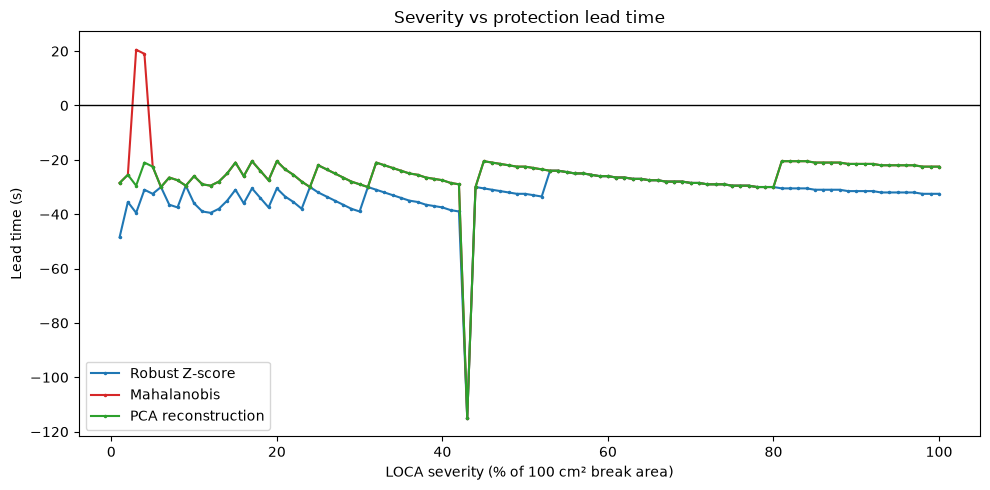

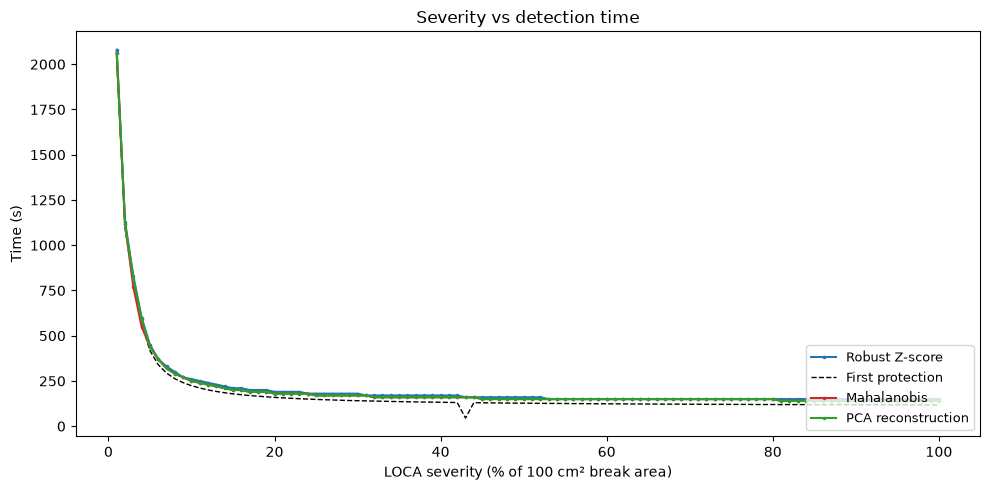

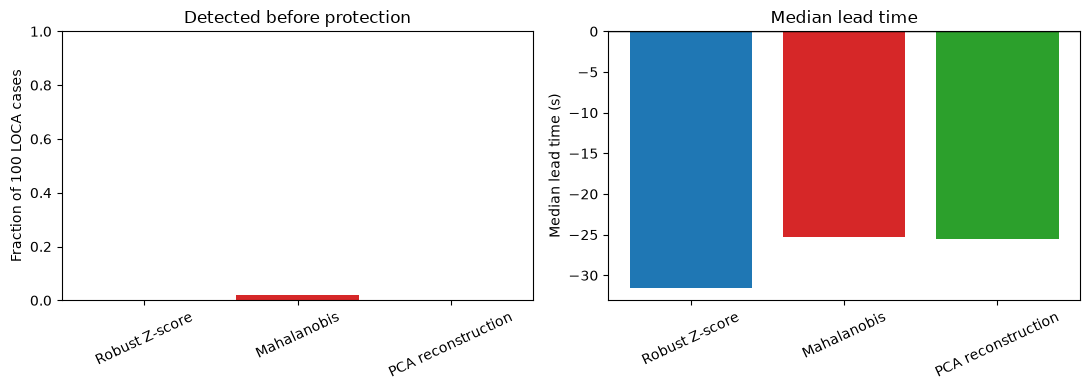

Figures: ['05_04_vs_05_preprotection_comparison.png', '05_severity_vs_detection_time.png', '05_severity_vs_lead_time.png', 'method_comparison.png', 'severity_vs_detection_time.png', 'severity_vs_lead_time.png']


In [4]:
import matplotlib.pyplot as plt

labels = {
    'robust_z_score': 'Robust Z-score',
    'mahalanobis': 'Mahalanobis',
    'pca_reconstruction_error': 'PCA reconstruction',
}
colors = {'robust_z_score': '#1f77b4', 'mahalanobis': '#d62728', 'pca_reconstruction_error': '#2ca02c'}

fig, ax = plt.subplots(figsize=(10, 5))
for method in METHODS:
    part = results.loc[results['method'].eq(method)]
    ax.plot(part['severity'], part['lead_time_s'], '.-', ms=3, label=labels[method], color=colors[method])
ax.axhline(0, color='black', lw=1)
ax.set(xlabel='LOCA severity (% of 100 cm² break area)', ylabel='Lead time (s)', title='Severity vs protection lead time')
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_ROOT / 'severity_vs_lead_time.png', dpi=160)
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
for method in METHODS:
    part = results.loc[results['method'].eq(method)]
    ax.plot(part['severity'], part['detection_time_s'], '.-', ms=3, label=labels[method], color=colors[method])
    if method == METHODS[0]:
        ax.plot(part['severity'], part['first_protection_time_s'], '--', color='black', lw=1, label='First protection')
ax.set(xlabel='LOCA severity (% of 100 cm² break area)', ylabel='Time (s)', title='Severity vs detection time')
ax.legend(loc='lower right', fontsize=9)
fig.tight_layout()
fig.savefig(FIGURES_ROOT / 'severity_vs_detection_time.png', dpi=160)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
summary_plot = method_summary.set_index('method').loc[list(METHODS)]
axes[0].bar([labels[m] for m in METHODS], summary_plot['protection_before_detected_rate'], color=[colors[m] for m in METHODS])
axes[0].set(ylim=(0, 1), ylabel='Fraction of 100 LOCA cases', title='Detected before protection')
axes[0].tick_params(axis='x', rotation=25)
axes[1].bar([labels[m] for m in METHODS], summary_plot['lead_time_median_s'], color=[colors[m] for m in METHODS])
axes[1].axhline(0, color='black', lw=1)
axes[1].set(ylabel='Median lead time (s)', title='Median lead time')
axes[1].tick_params(axis='x', rotation=25)
fig.tight_layout()
fig.savefig(FIGURES_ROOT / 'method_comparison.png', dpi=160)
plt.show()
print('Figures:', sorted(path.name for path in FIGURES_ROOT.glob('*.png')))


## Validation and interpretation

The assertions below check that all 100 cases were evaluated, that all model features are drawn from the audited 38-feature set, and that thresholds exist for all three methods. The expected interpretation is deliberately conservative: with one Normal trajectory and only 11 calibration rows, even a zero self-alarm result cannot be called an independent false-alarm rate. If protection-before-detection is low, the appropriate conclusion is that this simple reference baseline is not yet an effective early-warning detector for this dataset.

In [5]:
assert set(results['method']) == set(METHODS)
assert results.groupby('method').size().eq(100).all()
assert set(model.active_features).issubset(set(candidate_features))
assert len(set(model.active_features) & set(model.inactive_features)) == 0
assert set(model.thresholds) == set(METHODS)
assert results['first_protection_time_s'].notna().all()

print('Protection-before-detection summary:')
display(method_summary[['method', 'protection_before_detected_count', 'protection_before_detected_rate', 'lead_time_median_s', 'lead_time_min_s', 'lead_time_max_s', 'normal_reference_false_alarm']])
print('Interpretation: negative lead time means detection was confirmed after protection; Normal false-alarm status is in-sample because only one Normal trajectory exists.')


Protection-before-detection summary:


,method,protection_before_detected_count,protection_before_detected_rate,lead_time_median_s,lead_time_min_s,lead_time_max_s,normal_reference_false_alarm
0,robust_z_score,0,0.00,-31.50,-115.0,-24.0,False
1,mahalanobis,2,0.02,-25.25,-115.0,20.5,False
2,pca_reconstruction_error,0,0.00,-25.50,-115.0,-20.5,False


Interpretation: negative lead time means detection was confirmed after protection; Normal false-alarm status is in-sample because only one Normal trajectory exists.
